In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D


result_path = "output/results.csv"
df = pd.read_csv(result_path)


### Only square domains

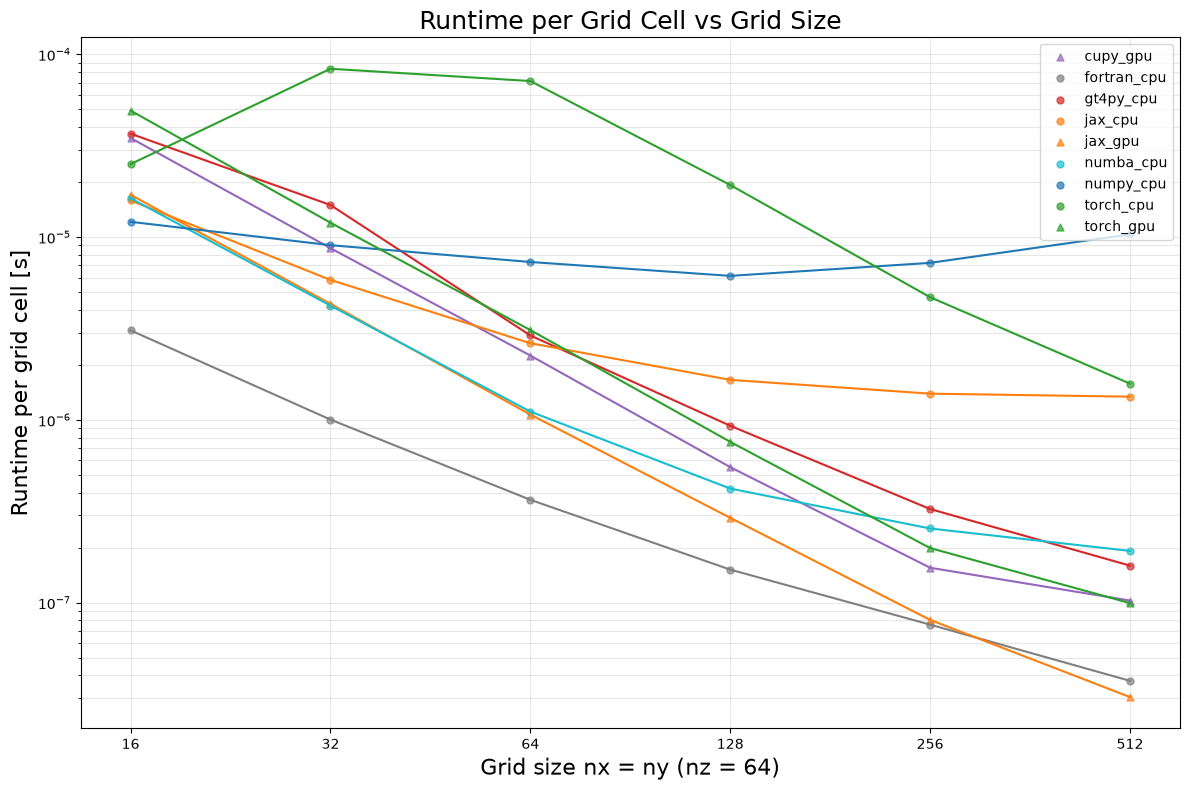

In [6]:
df_square = df[df["nx"] == df["ny"]]


df_square["gridsize"] = df_square["nx"]
grid_sizes = sorted(df_square["gridsize"].unique())


df_square["implementation"] = df_square["framework"] + "_" + df_square["device"]

plt.figure(figsize=(12, 8))


framework_colors = {
    "numpy": "tab:blue",
    "numba": "tab:cyan",
    "jax": "tab:orange",
    "torch": "tab:green",
    "cupy": "tab:purple",
    "gt4py": "tab:red",
    "fortran": "tab:gray",
}


device_markers = {
    "cpu": "o", 
    "gpu": "^", 
}



for impl, group in df_square.groupby("implementation"):
    framework = group["framework"].iloc[0]
    device = group["device"].iloc[0]

    average_runtime = group.groupby("gridsize", as_index=False)["time_per_work"].mean()
    
    plt.scatter(
        average_runtime["gridsize"],
        average_runtime["time_per_work"],
        label=impl,
        color=framework_colors[framework],
        marker=device_markers[device],
        alpha=0.7,
        s=25,
    )

    plt.plot(
        average_runtime["gridsize"],
        average_runtime["time_per_work"],
        linewidth = 1.5,
        color=framework_colors[framework],
    )

plt.xscale("log", base=2)
plt.xticks(grid_sizes, labels=[str(x) for x in grid_sizes])
plt.yscale("log")

plt.xlabel("Grid size nx = ny (nz = 64)", fontsize = 16)
plt.ylabel("Runtime per grid cell [s]", fontsize = 16)
plt.title("Runtime per Grid Cell vs Grid Size", fontsize = 18)
plt.grid(True, which="both", alpha=0.3)
plt.legend(loc="upper right")

plt.tight_layout()
plt.savefig("results/runtime_per_gridcell_vs_nx_quadratic_domain.png")
plt.show()


### All grid size combinations, grouped by working set size

[np.int64(49152), np.int64(98304), np.int64(196608), np.int64(393216), np.int64(786432), np.int64(1572864), np.int64(3145728), np.int64(6291456), np.int64(12582912), np.int64(25165824), np.int64(50331648), np.int64(100663296), np.int64(201326592)]


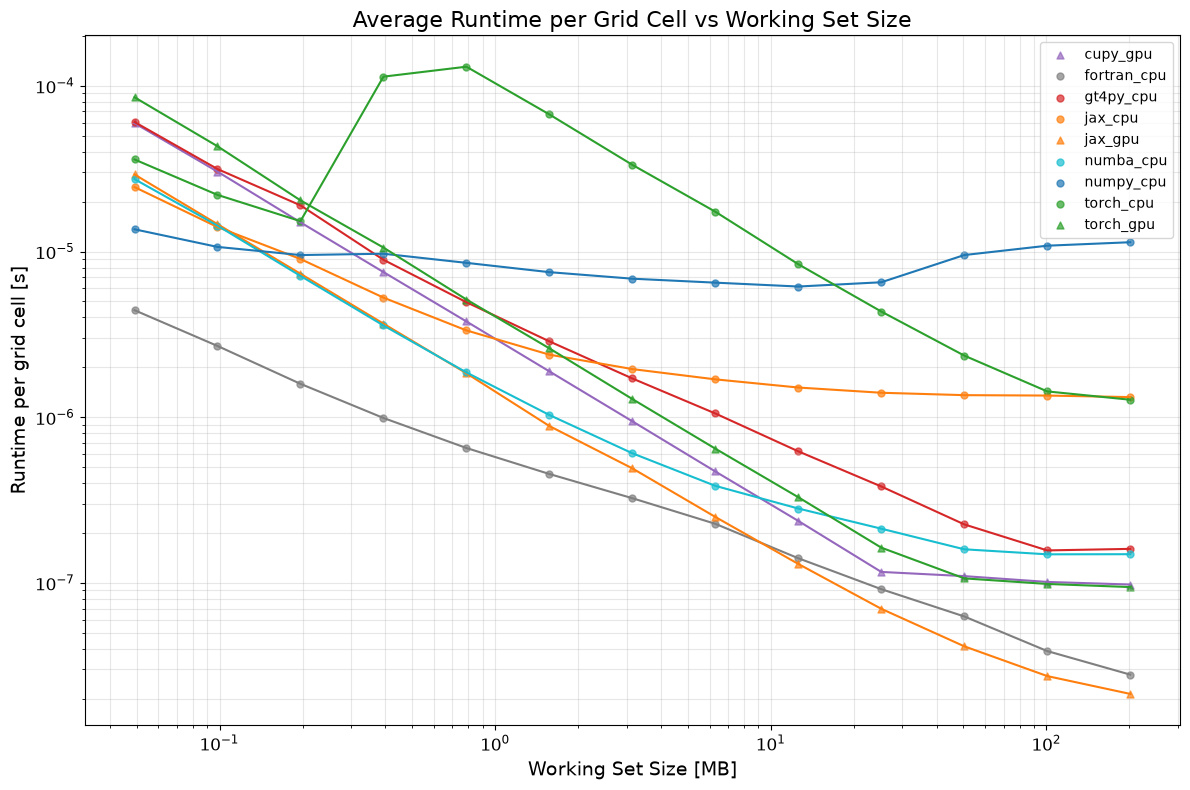

In [14]:
df["working_set_size"] = df["nx"]*df["ny"]*df["nz"]*3*4
working_set_size = sorted(df["working_set_size"].unique())
print(working_set_size)


df["implementation"] = df["framework"] + "_" + df["device"]

plt.figure(figsize=(12, 8))


framework_colors = {
    "numpy": "tab:blue",
    "numba": "tab:cyan",
    "jax": "tab:orange",
    "torch": "tab:green",
    "cupy": "tab:purple",
    "gt4py": "tab:red",
    "fortran": "tab:gray",
}


device_markers = {
    "cpu": "o",
    "gpu": "^", 
}

average_runtime = (
    df.groupby(
        ["framework", "device", "working_set_size"],
        as_index=False
    )["time_per_work"]
    .mean()
)


for (framework, device), group in average_runtime.groupby(["framework", "device"]):
    
    plt.scatter(
        group["working_set_size"]*1e-6,
        group["time_per_work"],
        label=f"{framework}_{device}",
        color=framework_colors[framework],
        marker=device_markers[device],
        alpha=0.7,
        s=25,
    )

    plt.plot(
        group["working_set_size"]*1e-6,
        group["time_per_work"],
        linewidth = 1.5,
        color=framework_colors[framework],
    )


plt.xscale("log", base=10)
plt.yscale("log")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.xlabel("Working Set Size [MB]", fontsize = 14)
plt.ylabel("Runtime per grid cell [s]", fontsize = 14)
plt.title("Average Runtime per Grid Cell vs Working Set Size", fontsize = 16)
plt.grid(True, which="both", alpha=0.3)
plt.legend(loc="upper right")

plt.tight_layout()
plt.savefig("results/runtime_per_gridcell_vs_working_set_size.png")
plt.show()


### GPU vs CPU speedup

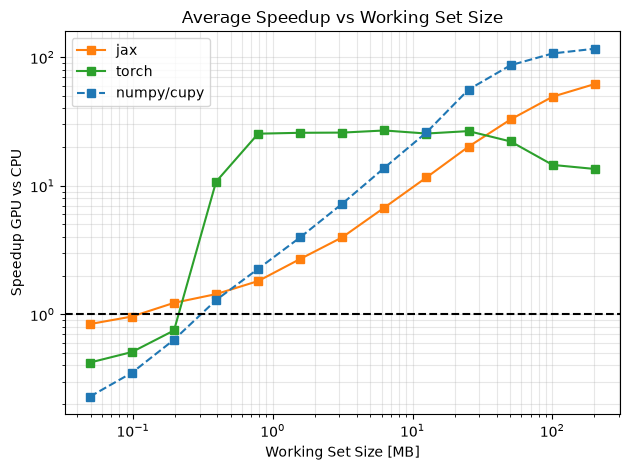

In [55]:
# Frameworks with both CPU and GPU implementations
frameworks = [
    fw for fw in average_runtime["framework"].unique()
    if {"cpu", "gpu"}.issubset(
        set(average_runtime[average_runtime["framework"] == fw]["device"])
    )
]

# Speedup for same framework
for framework in frameworks:
    cpu = average_runtime[
        (average_runtime["framework"] == framework) &
        (average_runtime["device"] == "cpu")
    ][["working_set_size", "time_per_work"]]

    gpu = average_runtime[
        (average_runtime["framework"] == framework) &
        (average_runtime["device"] == "gpu")
    ][["working_set_size", "time_per_work"]]

    merged = cpu.merge(
        gpu,
        on="working_set_size",
        suffixes=("_cpu", "_gpu")
    )

    merged["speedup"] = (
        merged["time_per_work_cpu"] /
        merged["time_per_work_gpu"]
    )

    merged = merged.sort_values("working_set_size")

    plt.plot(
        merged["working_set_size"]*1e-6,
        merged["speedup"],
        marker="s",
        linewidth=1.5,
        label=f"{framework}",
        color=framework_colors.get(framework, None),
    )

# NumPy CPU vs CuPy GPU
numpy_cpu = average_runtime[
    (average_runtime["framework"] == "numpy") &
    (average_runtime["device"] == "cpu")
][["working_set_size", "time_per_work"]]

cupy_gpu = average_runtime[
    (average_runtime["framework"] == "cupy") &
    (average_runtime["device"] == "gpu")
][["working_set_size", "time_per_work"]]

if not numpy_cpu.empty and not cupy_gpu.empty:
    merged = numpy_cpu.merge(
        cupy_gpu,
        on="working_set_size",
        suffixes=("_numpy", "_cupy")
    )

    merged["speedup"] = (
        merged["time_per_work_numpy"] /
        merged["time_per_work_cupy"]
    )

    merged = merged.sort_values("working_set_size")

    plt.plot(
        merged["working_set_size"]*1e-6,
        merged["speedup"],
        marker="s",
        linestyle="--",
        label = "numpy/cupy",
    )

plt.legend()
plt.xscale("log", base=10)
plt.yscale("log")
plt.axhline(y=1, linestyle = '--', color = 'black')

plt.xlabel("Working Set Size [MB]")
plt.ylabel("Speedup GPU vs CPU")
plt.title("Average Speedup vs Working Set Size")
plt.grid(True, which="both", alpha=0.3)
plt.legend(loc="upper left")

plt.tight_layout()
plt.savefig("results/gpu_vs_cpu_speedup.png")
plt.show()

### one working set size, different domain shapes

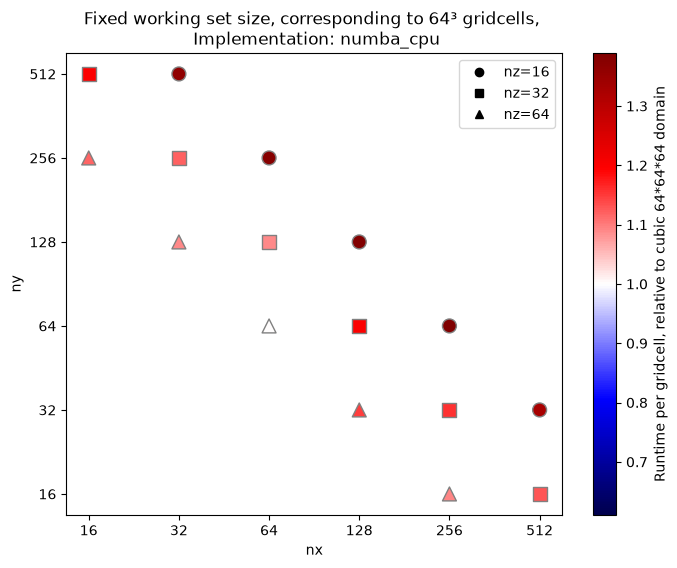

In [43]:
ws_ref = 64*64*64*3*4
fw = "numba"
backend = "cpu"

data = (
    df[
        (df["framework"] == fw) &
        (df["device"] == backend) &
        (df["working_set_size"] == ws_ref)
    ]
    .groupby(["nx", "ny", "nz"], as_index=False)["time_per_work"]
    .mean()
)

data["relative"] = data["time_per_work"] / data[(data["nx"] == 64) &(data["ny"] == 64) &(data["nz"] == 64)]["time_per_work"].iloc[0]

max_deviation = max(
    1 - data["relative"].min(),
    data["relative"].max() - 1
)

norm = TwoSlopeNorm(
    vmin=1 - max_deviation,
    vcenter=1,
    vmax=1 + max_deviation
)


markers = {
    16: "o",  
    32: "s",   
    64: "^",   
}

plt.figure(figsize=(8, 6))

for nz, group in data.groupby("nz"):
    sc = plt.scatter(
        group["nx"],
        group["ny"],
        c=group["relative"],
        cmap="seismic",
        norm=norm,
        marker=markers[nz],
        s=100,
        label=f"nz={nz}",
        edgecolors = 'grey'
    )

ticks = [16, 32, 64, 128, 256, 512]


handles = [
    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor='black', color='black',
           label='nz=16'),
    Line2D([0], [0], marker='s', linestyle='None',
           markerfacecolor='black', color='black',
           label='nz=32'),
    Line2D([0], [0], marker='^', linestyle='None',
           markerfacecolor='black', color='black',
           label='nz=64'),
]


plt.xscale("log", base=2)
plt.yscale("log", base=2)
plt.xticks(ticks, labels=ticks)
plt.yticks(ticks, labels=ticks)
plt.legend(handles = handles, loc = 'upper right')
plt.colorbar(sc, label="Runtime per gridcell, relative to cubic 64*64*64 domain")
plt.xlabel("nx")
plt.ylabel("ny")
plt.title(f"Fixed working set size, corresponding to 64³ gridcells, \n Implementation: {fw}_{backend}")
plt.savefig(f"results/relative_runtime_shapes_{fw}_{backend}.png")

### Again all grid size combinations, grouped by working set size, but with OMP_NUM_THREADS=1

[np.int64(49152), np.int64(98304), np.int64(196608), np.int64(393216), np.int64(786432), np.int64(1572864), np.int64(3145728), np.int64(6291456), np.int64(12582912), np.int64(25165824), np.int64(50331648), np.int64(100663296), np.int64(201326592)]


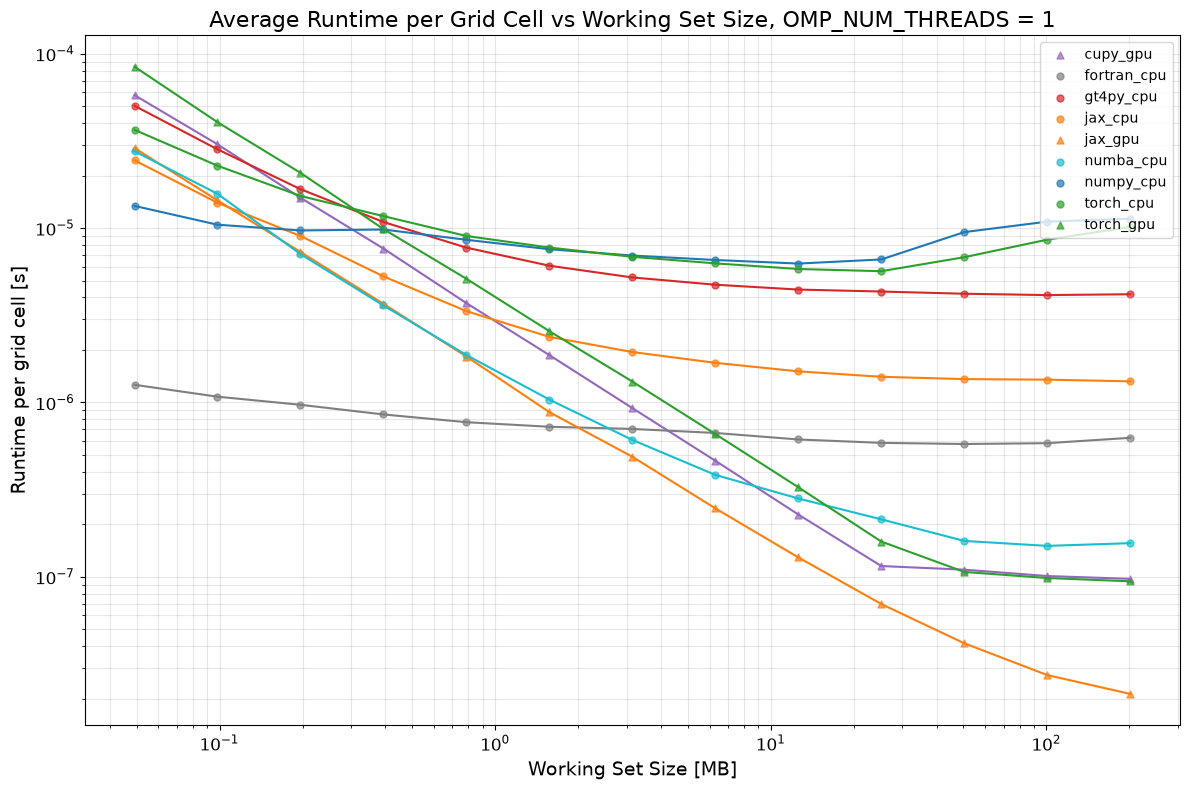

In [47]:
result_path = "output/results_OMPNUMTHREADS1.csv"
df = pd.read_csv(result_path)

df["working_set_size"] = df["nx"]*df["ny"]*df["nz"]*3*4
working_set_size = sorted(df["working_set_size"].unique())
print(working_set_size)

# Create implementation labels
df["implementation"] = df["framework"] + "_" + df["device"]

plt.figure(figsize=(12, 8))

framework_colors = {
    "numpy": "tab:blue",
    "numba": "tab:cyan",
    "jax": "tab:orange",
    "torch": "tab:green",
    "cupy": "tab:purple",
    "gt4py": "tab:red",
    "fortran": "tab:gray",
}

# one marker per device
device_markers = {
    "cpu": "o",  # circle
    "gpu": "^",  # triangle
}

average_runtime = (
    df.groupby(
        ["framework", "device", "working_set_size"],
        as_index=False
    )["time_per_work"]
    .mean()
)


for (framework, device), group in average_runtime.groupby(["framework", "device"]):
    
    plt.scatter(
        group["working_set_size"]*1e-6,
        group["time_per_work"],
        label=f"{framework}_{device}",
        color=framework_colors[framework],
        marker=device_markers[device],
        alpha=0.7,
        s=25,
    )

    plt.plot(
        group["working_set_size"]*1e-6,
        group["time_per_work"],
        linewidth = 1.5,
        color=framework_colors[framework],
    )


plt.xscale("log", base=10)
plt.yscale("log")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.xlabel("Working Set Size [MB]", fontsize = 14)
plt.ylabel("Runtime per grid cell [s]", fontsize = 14)
plt.title("Average Runtime per Grid Cell vs Working Set Size, OMP_NUM_THREADS = 1", fontsize = 16)
plt.grid(True, which="both", alpha=0.3)
plt.legend(loc="upper right")

plt.tight_layout()
plt.savefig("results/runtime_per_gridcell_vs_working_set_sizeOMPNUMTHREADS1.png")
plt.show()
